Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


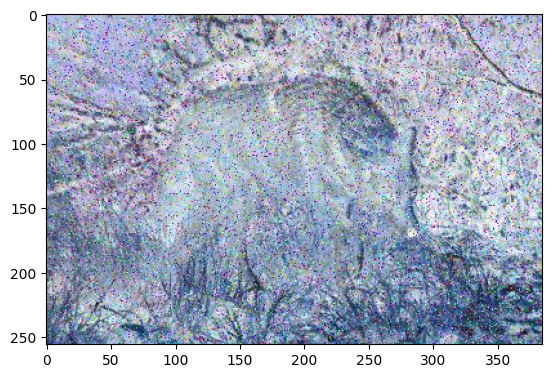

In [1]:
from google.colab import drive
import sys
import cv2
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
drive.mount('/content/drive')
sys.path.append('/content/drive/My Drive')
image = cv2.imread('/content/drive/My Drive/lisa.jpg')
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)

Проанализировав изображение было принято решение использовать инверсию из 2 лабораторной


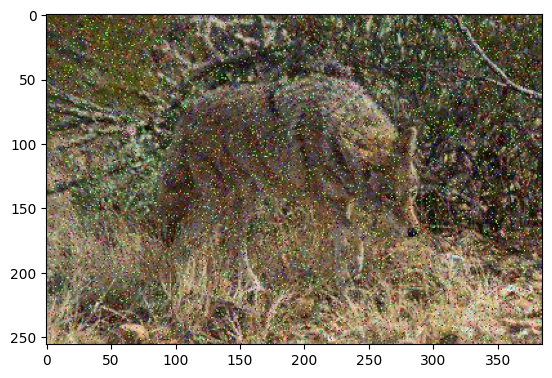

In [ ]:
lut = lambda i: 255 - i
invert_image = lut(rgb_image)
plt.imshow(invert_image)

Для устранения шумов было принято решение использовать медианный фильтр из 3 лабораторной

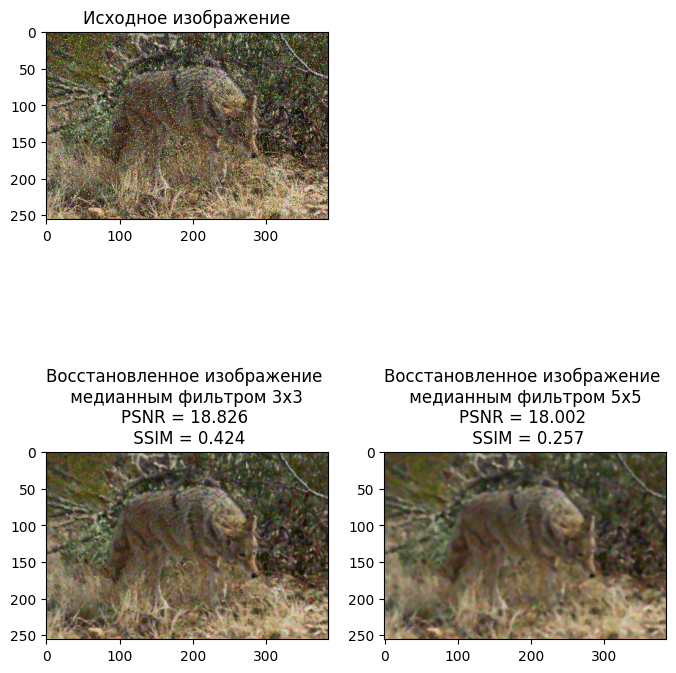

In [ ]:


def getSSIM(i1, i2):
    C1 = 6.5025  # для 8-битного изоражения
    C2 = 58.5225  # для 8-битного изоражения
    # INITS
    I1 = np.float32(i1)
    I2 = np.float32(i2)
    I2_2 = I2 * I2  # I2^2
    I1_2 = I1 * I1  # I1^2
    I1_I2 = I1 * I2  # I1 * I2

    mu1 = cv2.GaussianBlur(I1, (11, 11), 1.5)
    mu2 = cv2.GaussianBlur(I2, (11, 11), 1.5)
    mu1_2 = mu1 * mu1
    mu2_2 = mu2 * mu2
    mu1_mu2 = mu1 * mu2
    sigma1_2 = cv2.GaussianBlur(I1_2, (11, 11), 1.5)
    sigma1_2 -= mu1_2
    sigma2_2 = cv2.GaussianBlur(I2_2, (11, 11), 1.5)
    sigma2_2 -= mu2_2
    sigma12 = cv2.GaussianBlur(I1_I2, (11, 11), 1.5)
    sigma12 -= mu1_mu2
    t1 = 2 * mu1_mu2 + C1
    t2 = 2 * sigma12 + C2
    t3 = t1 * t2  # t3 = ((2*mu1_mu2 + C1).*(2*sigma12 + C2))
    t1 = mu1_2 + mu2_2 + C1
    t2 = sigma1_2 + sigma2_2 + C2
    t1 = t1 * t2  # t1 =((mu1_2 + mu2_2 + C1).*(sigma1_2 + sigma2_2 + C2))
    ssim_map = cv2.divide(t3, t1)  # ssim_map =  t3./t1;
    ssim = cv2.mean(ssim_map)  # mssim = average of ssim map
    ssim = ssim[:3]
    return ssim

def getPSNR(I1, I2):
    s1 = cv2.absdiff(I1, I2)  #|I1 - I2| - модуль разницы двух изображений
    s1 = np.float32(s1)
    s1 = s1 * s1  # |I1 - I2|^2
    sse = s1.sum()  # сумма элементов в каждом канале
    if sse <= 1e-10:  # сумма каналов
        return 0
    else:
        shape = I1.shape
        p=1
        for i in shape:
          p *= i
        mse = 1.0 * sse /p
        psnr = 10.0 * np.log10((255 * 255) / mse)
        return psnr

gs = plt.GridSpec(2, 2)
plt.figure(figsize=(8, 10))
plt.subplot(gs[0])
plt.imshow(invert_image)
plt.title('Исходное изображение')

median_image1 = cv2.medianBlur(invert_image, 3)
median_image2 = cv2.medianBlur(invert_image, 5)

plt.subplot(gs[2])
plt.imshow(median_image1, cmap='gray')
psnr = getPSNR(invert_image, median_image1)
ssim = getSSIM(invert_image, median_image1)
plt.title(f'Восстановленное изображение \n '
          f'медианным фильтром 3х3 \n'
          f'PSNR = {psnr:.3f} \n SSIM = {ssim[0]:.3f}')

plt.subplot(gs[3])
plt.imshow(median_image2, cmap='gray')
psnr = getPSNR(invert_image, median_image2)
ssim = getSSIM(invert_image, median_image2)
plt.title(f'Восстановленное изображение \n '
          f'медианным фильтром 5х5 \n'
          f'PSNR = {psnr:.3f} \n SSIM = {ssim[0]:.3f}')

plt.show()